<a href="https://colab.research.google.com/github/Nikil-Ralson/FaceMask/blob/main/FaceMask.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Activation, Flatten, BatchNormalization
import random
import cv2
import os
import json
from tensorflow.keras.models import Sequential
from tensorflow.keras import backend as k
from tensorflow.keras import optimizers
from sklearn.model_selection import train_test_split
import warnings
import zipfile
warnings.filterwarnings('ignore')

In [ ]:
with zipfile.ZipFile('/content/drive/MyDrive/archive (4).zip', 'r') as zip_ref:
  zip_ref.extractall('.')

In [ ]:
import tensorflow as tf
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available: 1


In [ ]:
directory = '/content/Medical mask/Medical mask/Medical Mask/annotations'
image_directory = '/content/Medical mask/Medical mask/Medical Mask/images'
df = pd.read_csv('/content/train.csv')
df_test = pd.read_csv('/content/submission.csv')

In [ ]:
cvNet = cv2.dnn.readNetFromCaffe('/content/drive/MyDrive/deploy.prototxt', '/content/drive/MyDrive/mobilenet_iter_73000.caffemodel')
def getJSON(filePathName):
  with open(filePathName, 'r') as f:
    return json.load(f)

def adjust_gamma(image,gamma=1):
  invGamma = 1.0/ gamma
  table = np.array([((i/255.0) ** invGamma) * 255 for i in np.arange(0,256)])
  return cv2.LUT(image.astype(np.uint8), table.astype(np.uint8))

In [ ]:
#Data preprocessing

jsonfiles= []
for i in os.listdir(directory):
  jsonfiles.append(getJSON(os.path.join(directory,i)))
jsonfiles[0]

{'FileName': '3241.png',
 'NumOfAnno': 8,
 'Annotations': [{'isProtected': False,
   'ID': 753236408438749952,
   'BoundingBox': [440, 23, 599, 222],
   'classname': 'face_other_covering',
   'Confidence': 1,
   'Attributes': {}},
  {'isProtected': False,
   'ID': 487437505949502720,
   'BoundingBox': [51, 37, 231, 286],
   'classname': 'face_with_mask',
   'Confidence': 1,
   'Attributes': {}},
  {'isProtected': False,
   'ID': 482808357778528384,
   'BoundingBox': [250, 28, 410, 264],
   'classname': 'face_with_mask',
   'Confidence': 1,
   'Attributes': {}},
  {'isProtected': False,
   'ID': 55513489500378376,
   'BoundingBox': [307, 163, 409, 260],
   'classname': 'mask_surgical',
   'Confidence': 1,
   'Attributes': {}},
  {'isProtected': False,
   'ID': 156938400273988992,
   'BoundingBox': [104, 187, 221, 284],
   'classname': 'mask_colorful',
   'Confidence': 1,
   'Attributes': {}},
  {'isProtected': False,
   'ID': 81924393122251520,
   'BoundingBox': [448, 24, 597, 131],
   

In [ ]:
df = pd.read_csv('/content/train.csv')
df.head()

,name,x1,x2,y1,y2,classname
0,2756.png,69,126,294,392,face_with_mask
1,2756.png,505,10,723,283,face_with_mask
2,2756.png,75,252,264,390,mask_colorful
3,2756.png,521,136,711,277,mask_colorful
4,6098.jpg,360,85,728,653,face_no_mask


In [ ]:
data = []
img_size = 124
mask = ['face_with_mask']
non_mask = ["face_no_mask"]
labels={'mask':0,'without mask':1}
for i in df["name"].unique():
    f = i+".json"
    for j in getJSON(os.path.join(directory,f)).get("Annotations"):
        if j["classname"] in mask:
            x,y,w,h = j["BoundingBox"]
            img = cv2.imread(os.path.join(image_directory,i),1)
            img = img[y:h,x:w]
            img = cv2.resize(img,(img_size,img_size))
            data.append([img,labels["mask"]])
        if j["classname"] in non_mask:
            x,y,w,h = j["BoundingBox"]
            img = cv2.imread(os.path.join(image_directory,i),1)
            img = img[y:h,x:w]
            img = cv2.resize(img,(img_size,img_size))
            data.append([img,labels["without mask"]])
random.shuffle(data)

<Axes: xlabel='count'>

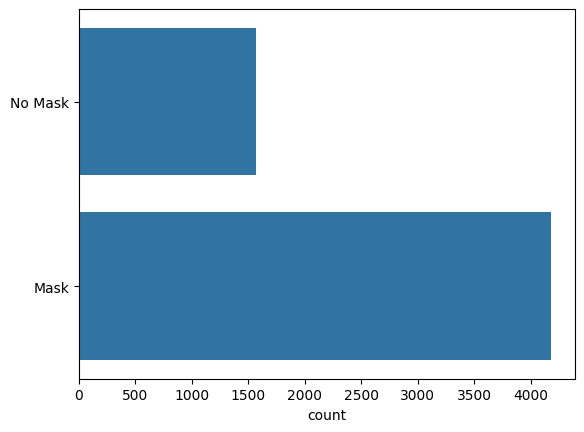

In [ ]:
p = []
for face in data:
    if(face[1] == 0):
        p.append("Mask")
    else:
        p.append("No Mask")
sns.countplot(p)

In [ ]:
#reshape
X = []
Y = []

for features,label in data:
  X.append(features)
  Y.append(label)

X = np.array(X)/255.0
X = X.reshape(-1,124,124,3)
Y = np.array(Y)

In [ ]:
model = Sequential()

model.add(Conv2D(32, (3,3), padding = 'same', activation='relu', input_shape=(124,124,3)))
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dropout(0.5))
model.add(Dense(50, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X,Y, train_size=0.8, random_state=0)

datagen = ImageDataGenerator(
    featurewise_center=False,
    samplewise_center=False,
    featurewise_std_normalization=False,
    samplewise_std_normalization=False,
    zca_whitening=False,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=False
)

datagen.fit(X_train)

In [ ]:
history = model.fit(datagen.flow(X_train, y_train, batch_size=32),
                              steps_per_epoch=X_train.shape[0]//32,
                              epochs=50,
                              verbose=1,
                              validation_data=(X_val, y_val))

Epoch 1/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 48s 240ms/step - accuracy: 0.7741 - loss: 0.8417 - val_accuracy: 0.8983 - val_loss: 0.2650
Epoch 2/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9375 - loss: 0.1730 - val_accuracy: 0.9043 - val_loss: 0.2649
Epoch 3/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 21s 147ms/step - accuracy: 0.8649 - loss: 0.3072 - val_accuracy: 0.9017 - val_loss: 0.2458
Epoch 4/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9062 - loss: 0.3466 - val_accuracy: 0.8983 - val_loss: 0.2448
Epoch 5/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 41s 151ms/step - accuracy: 0.8828 - loss: 0.2802 - val_accuracy: 0.9139 - val_loss: 0.2250
Epoch 6/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9062 - loss: 0.2551 - val_accuracy: 0.9078 - val_loss: 0.2316
Epoch 7/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 22s 150ms/step - accuracy: 0.8898 - loss: 0.2759 - val_accuracy: 0.9139 - val_loss: 0.2018
Epoch 8/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8750 - loss: 0.3787 - val_

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


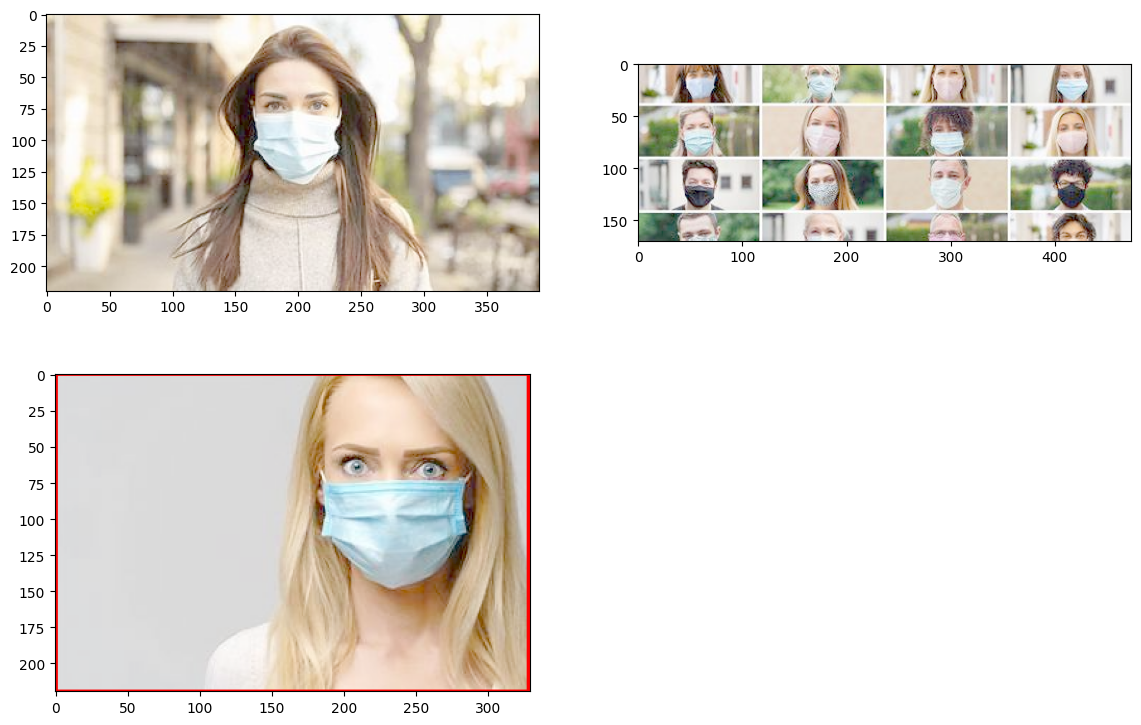

In [ ]:
test_images = ['/content/mask1.jpeg','/content/mask3.jpeg', '/content/mask2.jpeg']

gamma = 2.0
fig = plt.figure(figsize = (14,14))
rows = 3
cols = 2
axes = []
assign = {'0':'Mask','1':"No Mask"}
for j,im in enumerate(test_images):
    image =  cv2.imread(im,1)
    image =  adjust_gamma(image, gamma=gamma)
    (h, w) = image.shape[:2]
    blob = cv2.dnn.blobFromImage(cv2.resize(image, (300,300)), 1.0, (300, 300), (104.0, 177.0, 123.0))
    cvNet.setInput(blob)
    detections = cvNet.forward()
    for i in range(0, detections.shape[2]):
        try:
            box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
            (startX, startY, endX, endY) = box.astype("int")
            frame = image[startY:endY, startX:endX]
            confidence = detections[0, 0, i, 2]
            if confidence > 0.2:
                im = cv2.resize(frame,(img_size,img_size))
                im = np.array(im)/255.0
                im = im.reshape(1,124,124,3)
                result = model.predict(im)
                if result>0.5:
                    label_Y = 1
                else:
                    label_Y = 0
                cv2.rectangle(image, (startX, startY), (endX, endY), (0, 0, 255), 2)
                cv2.putText(image,assign[str(label_Y)] , (startX, startY-10), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (36,255,12), 2)

        except:pass
    axes.append(fig.add_subplot(rows, cols, j+1))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.show()